# Neural Network 

Tasks: 
1. AND Gate Neural Network
2. XOR Gate Neural Network
3. Batch, Iteration, and Epoch
4. Iris Dataset Classification
5. MNIST Classification with Improved Accuracy

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms

## Task 1: AND Gate Neural Network

Implementing a single neuron neural network for the AND gate. Truth table:

| Input 1 | Input 2 | Output |
|---------|---------|--------|
| 0       | 0       | 0      |
| 0       | 1       | 0      |
| 1       | 0       | 0      |
| 1       | 1       | 1      |

In [14]:
# AND Gate data
X = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y = torch.tensor([[0], [0], [0], [1]], dtype=torch.float32)

In [15]:
class SingleNeuronNet(nn.Module):
    def __init__(self):
        super(SingleNeuronNet, self).__init__()
        self.layer = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        return self.sigmoid(self.layer(x))

In [16]:
# Initialize model, loss function, and optimizer
model_and = SingleNeuronNet()
criterion = nn.BCELoss()
optimizer = optim.SGD(model_and.parameters(), lr=0.1)

In [17]:
# Training loop
epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = model_and(X)
    loss = criterion(outputs, y)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        losses.append(loss.item())
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.4556
Epoch [200/1000], Loss: 0.3591
Epoch [300/1000], Loss: 0.2991
Epoch [400/1000], Loss: 0.2575
Epoch [500/1000], Loss: 0.2267
Epoch [600/1000], Loss: 0.2028
Epoch [700/1000], Loss: 0.1835
Epoch [800/1000], Loss: 0.1676
Epoch [900/1000], Loss: 0.1542
Epoch [1000/1000], Loss: 0.1428


In [18]:
# Test the model
with torch.no_grad():
    predictions = model_and(X)
    predicted = (predictions > 0.5).float()
    accuracy = (predicted == y).float().mean()
    print(f'\nFinal predictions:\n{predictions}')
    print(f'Rounded predictions:\n{predicted}')
    print(f'Accuracy: {accuracy.item()*100}%')


Final predictions:
tensor([[0.0082],
        [0.1494],
        [0.1489],
        [0.7871]])
Rounded predictions:
tensor([[0.],
        [0.],
        [0.],
        [1.]])
Accuracy: 100.0%


In [19]:
# Save the model
torch.save(model_and.state_dict(), 'and_gate_model.pth')

## Task 2: XOR Gate Neural Network

Implementing a neural network for the XOR gate. Truth table:

| Input 1 | Input 2 | Output |
|---------|---------|--------|
| 0       | 0       | 0      |
| 0       | 1       | 1      |
| 1       | 0       | 1      |
| 1       | 1       | 0      |

Note: XOR is not linearly separable, so we'll need a hidden layer.

In [7]:
# XOR Gate data
X_xor = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y_xor = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

In [10]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()  
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        return self.sigmoid(self.output(x))

In [11]:
# Initialize model, loss function, and optimizer
model_xor = XORNet()
criterion = nn.BCELoss()
optimizer = optim.SGD(model_xor.parameters(), lr=0.1)

In [12]:
# Training loop
epochs = 5000
losses_xor = []

for epoch in range(epochs):
    # Forward pass
    outputs = model_xor(X_xor)
    loss = criterion(outputs, y_xor)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 500 == 0:
        losses_xor.append(loss.item())
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [500/5000], Loss: 0.6932
Epoch [1000/5000], Loss: 0.6929
Epoch [1500/5000], Loss: 0.6926
Epoch [2000/5000], Loss: 0.6920
Epoch [2500/5000], Loss: 0.6905
Epoch [3000/5000], Loss: 0.6860
Epoch [3500/5000], Loss: 0.6690
Epoch [4000/5000], Loss: 0.6159
Epoch [4500/5000], Loss: 0.5103
Epoch [5000/5000], Loss: 0.3693


In [13]:
# Test the model
with torch.no_grad():
    predictions = model_xor(X_xor)
    predicted = (predictions > 0.5).float()
    accuracy = (predicted == y_xor).float().mean()
    print(f'\nFinal predictions:\n{predictions}')
    print(f'Rounded predictions:\n{predicted}')
    print(f'Accuracy: {accuracy.item()*100}%')


Final predictions:
tensor([[0.1433],
        [0.6569],
        [0.7714],
        [0.4734]])
Rounded predictions:
tensor([[0.],
        [1.],
        [1.],
        [0.]])
Accuracy: 100.0%


In [14]:
# Save the model
torch.save(model_xor.state_dict(), 'xor_gate_model.pth')

## Task 3: Understanding Batch, Iteration, and Epoch

### Key Concepts:

1. **Batch**:
   - A subset of the training dataset used in one training iteration
   - Helps in efficient memory usage and improved training stability
   - Example: If batch_size = 32, each training iteration processes 32 samples

2. **Iteration**:
   - One forward and backward pass of a batch through the network
   - Number of iterations per epoch = Total samples / Batch size
   - Example: With 1000 samples and batch_size = 100, each epoch has 10 iterations

3. **Epoch**:
   - One complete pass through the entire training dataset
   - Multiple epochs help the model learn patterns in the data better
   - Example: If training for 10 epochs with 1000 samples and batch_size = 100:
     - Each epoch: 10 iterations
     - Total iterations: 10 epochs × 10 iterations = 100 iterations


## Task 4: Iris Dataset Classification

Implementing a simple neural network for the Iris dataset classification task.
- Features: sepal length, sepal width, petal length, petal width
- Classes: setosa, versicolor, virginica

In [26]:
# Load and prepare Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

In [44]:
y

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

In [28]:
# Convert to PyTorch tensors
X = torch.FloatTensor(X)
y = torch.LongTensor(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.layer1 = nn.Linear(4, 8)
        self.layer2 = nn.Linear(8, 3)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        return self.layer2(x)

In [30]:
# Initialize model, loss function, and optimizer
model_iris = IrisNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iris.parameters(), lr=0.01)

In [31]:
# Training loop
epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training
    model_iris.train()
    outputs = model_iris(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model_iris.eval()
    with torch.no_grad():
        test_outputs = model_iris(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses.append(test_loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Validation Loss: {test_loss.item():.4f}')

Epoch [10/100], Train Loss: 0.9596, Validation Loss: 0.9625
Epoch [20/100], Train Loss: 0.7938, Validation Loss: 0.7843
Epoch [30/100], Train Loss: 0.6815, Validation Loss: 0.6784
Epoch [40/100], Train Loss: 0.5856, Validation Loss: 0.5932
Epoch [50/100], Train Loss: 0.5079, Validation Loss: 0.5299
Epoch [60/100], Train Loss: 0.4437, Validation Loss: 0.4682
Epoch [70/100], Train Loss: 0.3843, Validation Loss: 0.4040
Epoch [80/100], Train Loss: 0.3320, Validation Loss: 0.3514
Epoch [90/100], Train Loss: 0.2838, Validation Loss: 0.3069
Epoch [100/100], Train Loss: 0.2405, Validation Loss: 0.2680


In [32]:
# Evaluate the model
model_iris.eval()
with torch.no_grad():
    test_outputs = model_iris(X_test)
    _, predicted = torch.max(test_outputs.data, 1)
    accuracy = (predicted == y_test).float().mean()
    print(f'\nTest Accuracy: {accuracy.item()*100:.2f}%')


Test Accuracy: 96.67%


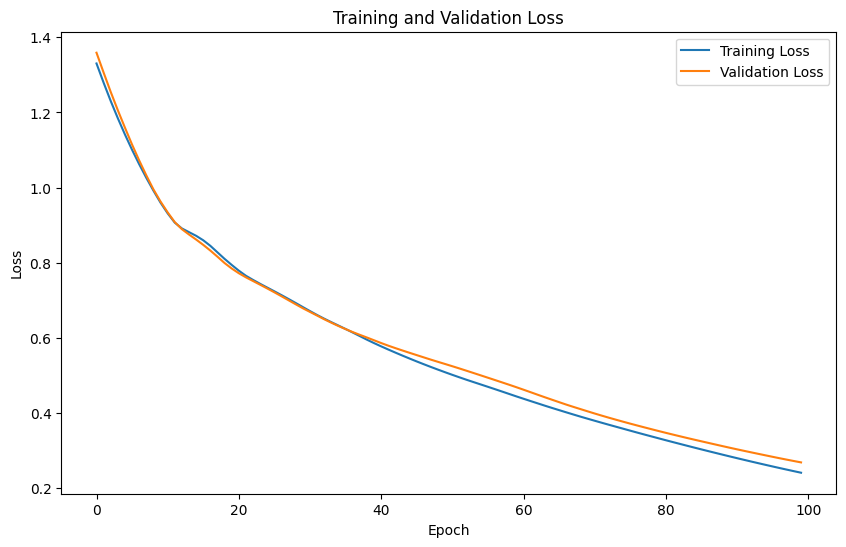

In [33]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Task 5: FashionMNIST Classification (PyTorch Quickstart)

Implementing a neural network for FashionMNIST classification with >78% accuracy following the PyTorch quickstart tutorial.

In [34]:
# Download FashionMNIST training data
training_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)

# Download FashionMNIST test data
test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)

# Labels for FashionMNIST
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Create data loaders
batch_size = 128
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [36]:
model = NeuralNetwork()
print("Model structure:", model)

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [37]:
# Training function
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [38]:
# Testing function
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return 100*correct

In [39]:
# Training loop
epochs = 15
test_accuracies = []

print("Starting training...")
for t in range(epochs):
    print(f"Epoch {t+1}\n")
    train(train_dataloader, model, loss_fn, optimizer)
    accuracy = test(test_dataloader, model, loss_fn)
    test_accuracies.append(accuracy)

Starting training...
Epoch 1

loss: 2.362067  [    0/60000]
loss: 0.495304  [12800/60000]
loss: 0.502779  [25600/60000]
loss: 0.438799  [38400/60000]
loss: 0.420168  [51200/60000]
Test Error: 
 Accuracy: 85.4%, Avg loss: 0.395484 

Epoch 2

loss: 0.436189  [    0/60000]
loss: 0.367621  [12800/60000]
loss: 0.346514  [25600/60000]
loss: 0.480362  [38400/60000]
loss: 0.343462  [51200/60000]
Test Error: 
 Accuracy: 86.9%, Avg loss: 0.357903 

Epoch 3

loss: 0.312652  [    0/60000]
loss: 0.339196  [12800/60000]
loss: 0.362663  [25600/60000]
loss: 0.235618  [38400/60000]
loss: 0.353096  [51200/60000]
Test Error: 
 Accuracy: 88.1%, Avg loss: 0.333425 

Epoch 4

loss: 0.379536  [    0/60000]
loss: 0.283879  [12800/60000]
loss: 0.284891  [25600/60000]
loss: 0.290242  [38400/60000]
loss: 0.246030  [51200/60000]
Test Error: 
 Accuracy: 87.8%, Avg loss: 0.331241 

Epoch 5

loss: 0.267147  [    0/60000]
loss: 0.332957  [12800/60000]
loss: 0.271173  [25600/60000]
loss: 0.375745  [38400/60000]
loss: 

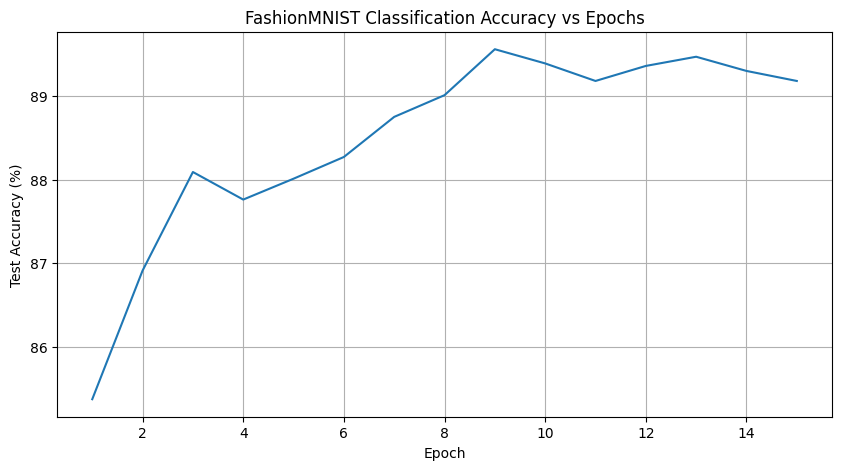

In [40]:
# Plot accuracy progression
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), test_accuracies)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('FashionMNIST Classification Accuracy vs Epochs')
plt.grid(True)
plt.show()

In [41]:
# Print final accuracy
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")

Final Test Accuracy: 89.18%


In [42]:
# Save the model
torch.save(model.state_dict(), 'fashion_mnist_model.pth')

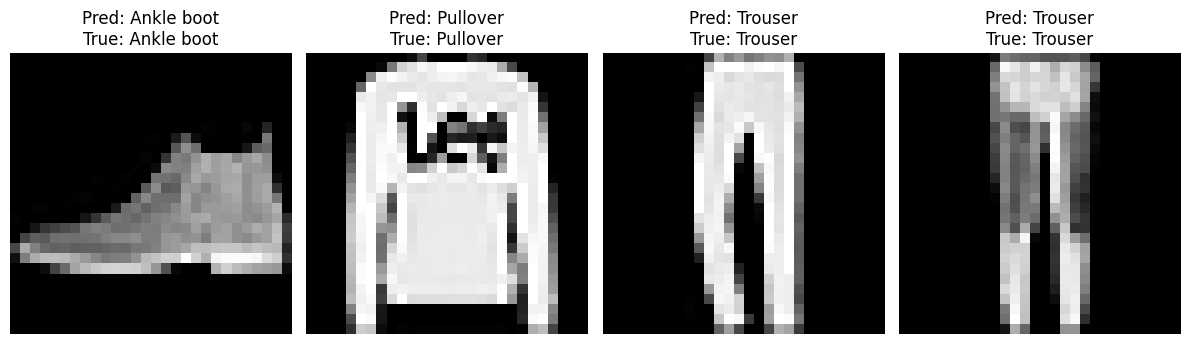

In [43]:
# Test with sample predictions
model.eval()
with torch.no_grad():
    # Get sample test images
    test_images, test_labels = next(iter(test_dataloader))
    predictions = model(test_images)
    
    # Plot sample results
    plt.figure(figsize=(12, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(test_images[i].squeeze(), cmap='gray')
        pred_label = classes[predictions[i].argmax()]
        true_label = classes[test_labels[i]]
        plt.title(f'Pred: {pred_label}\nTrue: {true_label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()